In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
test = pd.read_csv('D:/mythings/Dataset/HousePrice/Housing Prices Competition for Kaggle Learn Users/test.csv')
train = pd.read_csv('D:/mythings/Dataset/HousePrice/Housing Prices Competition for Kaggle Learn Users/train.csv')

In [3]:
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [4]:
train.describe()
# outliers may lie in LotFrontage, LotArea, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF,
# TotalBsmtSF

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
missing_value_counts = train.isnull().sum()
missing_value_counts

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [7]:
missing_value_features = ['LotFrontage','Alley','MasVnrType','MasVnrArea','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','Electrical','FireplaceQu','GarageType','GarageYrBlt','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']
train[missing_value_features]

,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,NaN,BrkFace,196.0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,2003.0,RFn,TA,TA,NaN,NaN,NaN
1,80.0,NaN,NaN,0.0,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,1976.0,RFn,TA,TA,NaN,NaN,NaN
2,68.0,NaN,BrkFace,162.0,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,2001.0,RFn,TA,TA,NaN,NaN,NaN
3,60.0,NaN,NaN,0.0,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,1998.0,Unf,TA,TA,NaN,NaN,NaN
4,84.0,NaN,BrkFace,350.0,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,2000.0,RFn,TA,TA,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62.0,NaN,NaN,0.0,Gd,TA,No,Unf,Unf,SBrkr,TA,Attchd,1999.0,RFn,TA,TA,NaN,NaN,NaN
1456,85.0,NaN,Stone,119.0,Gd,TA,No,ALQ,Rec,SBrkr,TA,Attchd,1978.0,Unf,TA,TA,NaN,MnPrv,NaN
1457,66.0,NaN,NaN,0.0,TA,Gd,No,GLQ,Unf,SBrkr,Gd,Attchd,1941.0,RFn,TA,TA,NaN,GdPrv,Shed
1458,68.0,NaN,NaN,0.0,TA,TA,Mn,GLQ,Rec,FuseA,NaN,Attchd,1950.0,Unf,TA,TA,NaN,NaN,NaN


## Data Visualisation

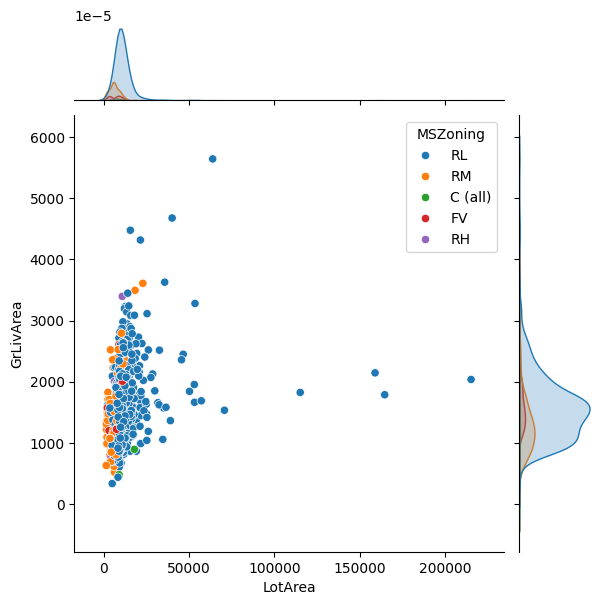

In [ ]:
sns.jointplot(train, x = 'LotArea', y = 'GrLivArea', hue ='MSZoning')
# GrLivArea might be greater if LotArea is small, which means ground living area is ultilised 
# and built into building or many stories of a house
# Outliers might lie in LotArea with MSZoning RL

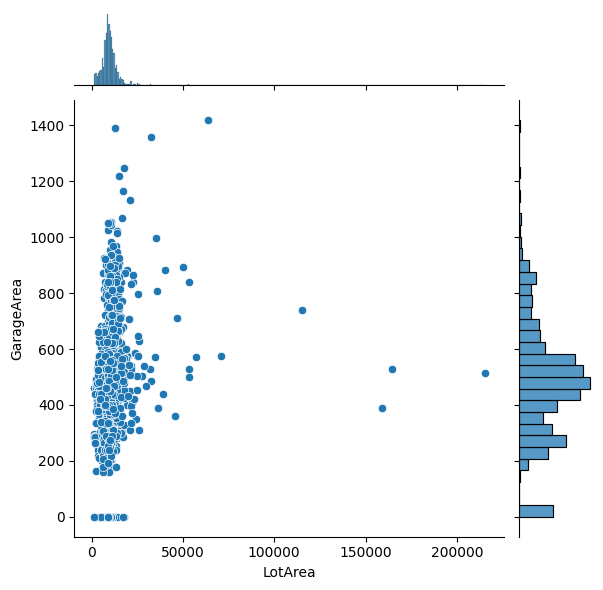

In [148]:
sns.jointplot(train, x = 'LotArea', y ='GarageArea')

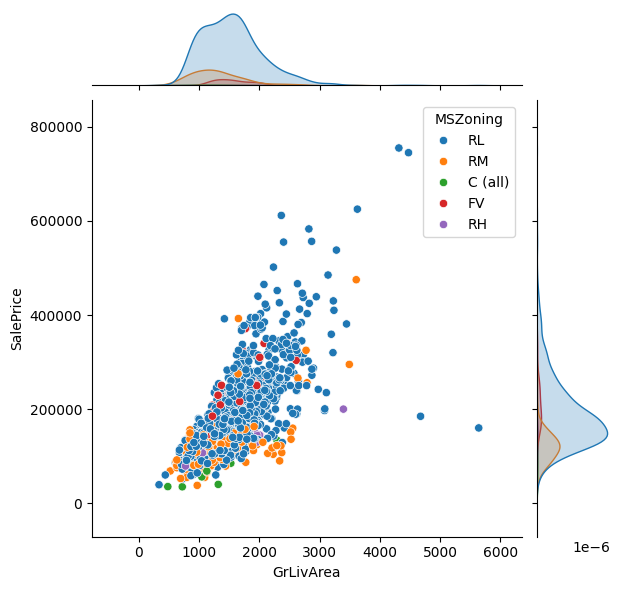

In [ ]:
sns.jointplot(train, x = 'GrLivArea', y ='SalePrice', hue = 'MSZoning')

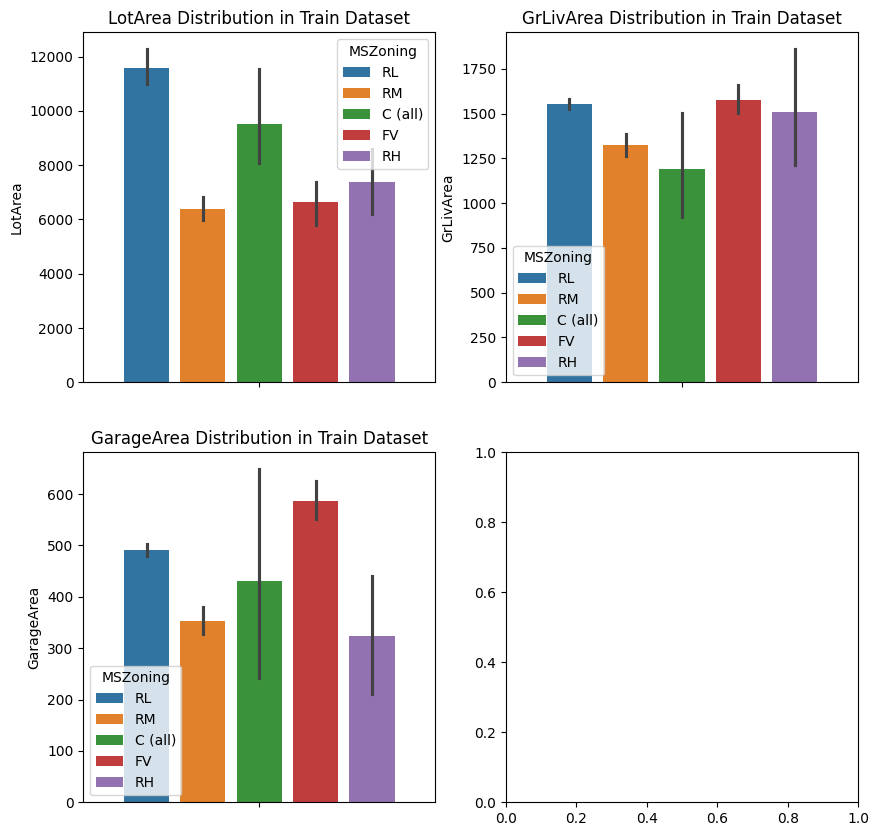

In [134]:
Area = ['LotArea','GrLivArea','GarageArea']
_, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (10,10))
for index, col in enumerate(Area):
    r = index // 2
    c = index % 2
    sns.barplot(train,y = col, ax = ax[r][c], hue = 'MSZoning', gap = 0.2)
    ax[r][c].set_title(f'{col} Distribution in Train Dataset')

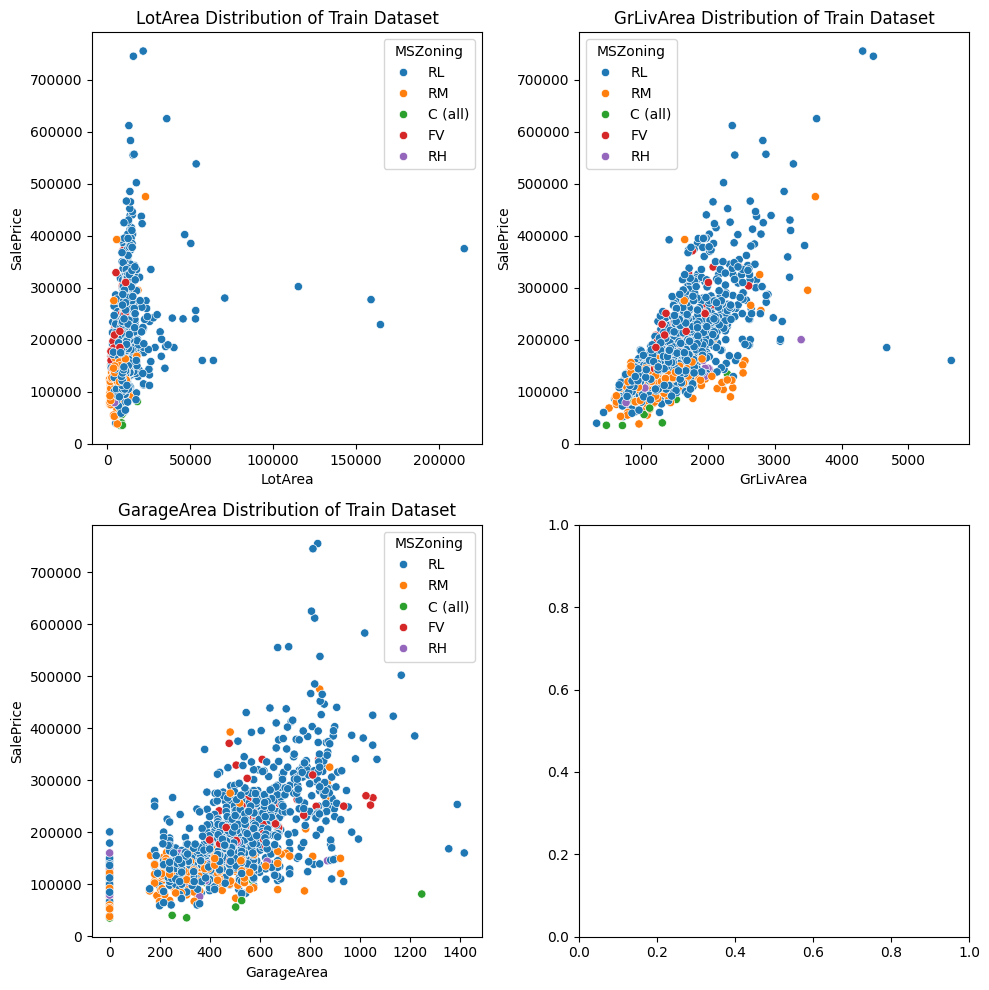

In [68]:
_, ax = plt.subplots(nrows = 2, ncols = 2, figsize =(10,10))
for index, col in enumerate(Area):
    r = index // 2
    c = index % 2
    sns.scatterplot(train, x = col, y = 'SalePrice', ax = ax[r][c],hue = 'MSZoning')
    ax[r][c].set_title(f'{col} Distribution of Train Dataset')
    plt.tight_layout()
## Outliers might lie in RL

<Axes: xlabel='GrLivArea', ylabel='Count'>

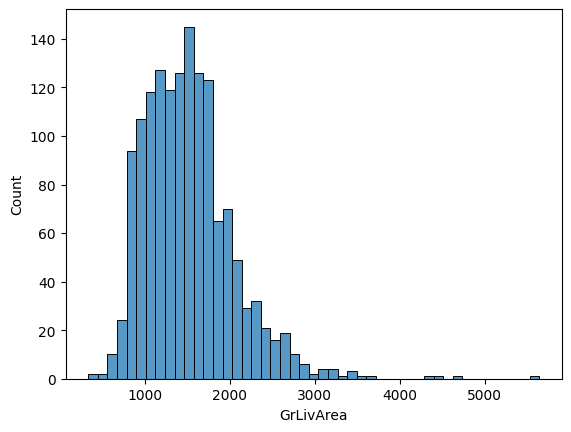

In [172]:
sns.histplot(train, x ='GrLivArea')

<Axes: xlabel='TotRmsAbvGrd', ylabel='count'>

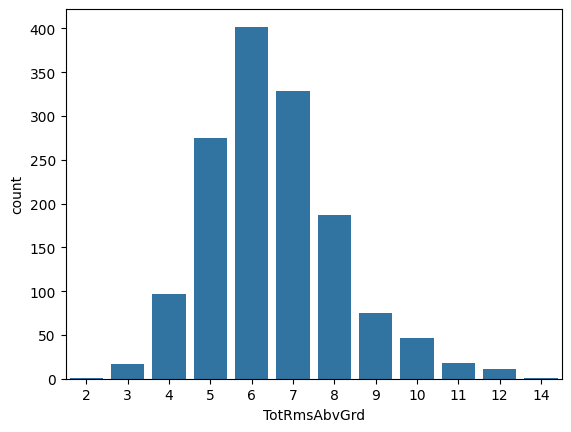

In [174]:
sns.countplot(train, x = 'TotRmsAbvGrd')

<Axes: xlabel='MoSold', ylabel='count'>

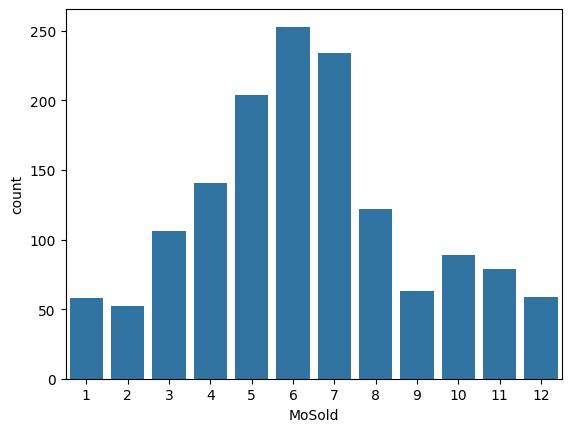

In [186]:
sns.countplot(train, x ='MoSold')

C:\Users\Rice\AppData\Local\Temp\ipykernel_5276\3840068337.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train, x = 'HouseStyle', palette = 'Set1')


<Axes: xlabel='HouseStyle', ylabel='count'>

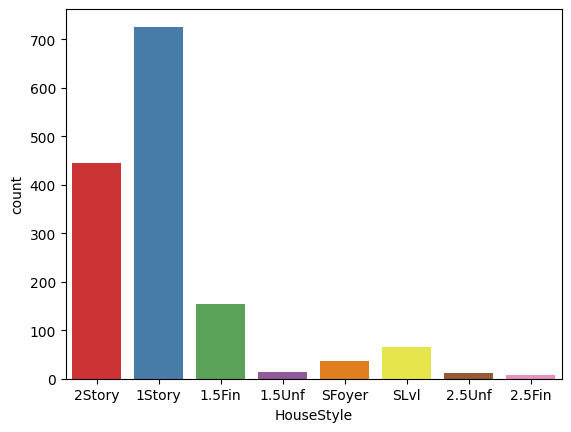

In [ ]:
sns.countplot(train, x = 'HouseStyle', palette = 'Set1')
# 1Story is the most popular style of houses

<Axes: xlabel='OverallCond', ylabel='count'>

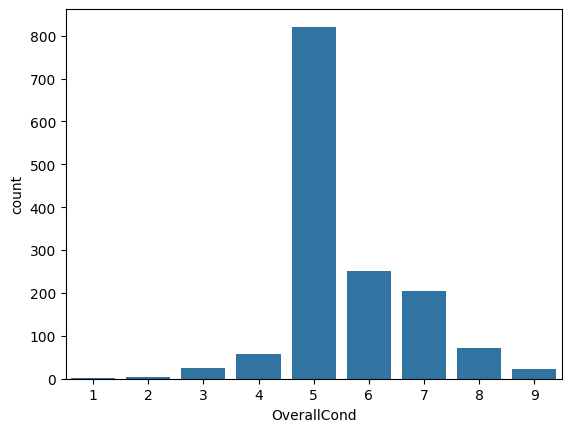

In [211]:
sns.countplot(train, x = 'OverallCond')

<Axes: xlabel='MSSubClass', ylabel='count'>

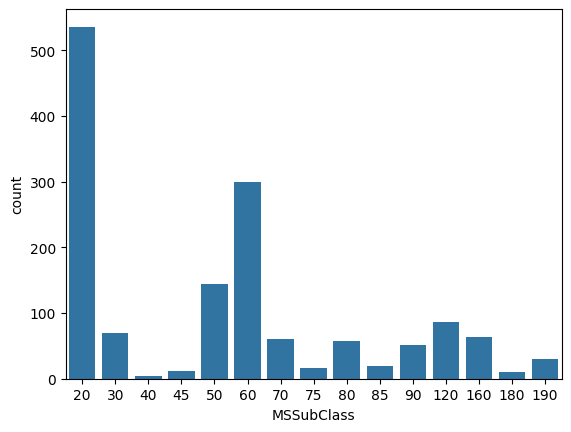

In [ ]:
sns.countplot(train, x ='MSSubClass')
# Majority type of houses is 20  (1-STORY 1946 & NEWER ALL STYLES)

C:\Users\Rice\AppData\Local\Temp\ipykernel_5276\355341292.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train, x = 'MSZoning', palette='Set1')


<Axes: xlabel='MSZoning', ylabel='count'>

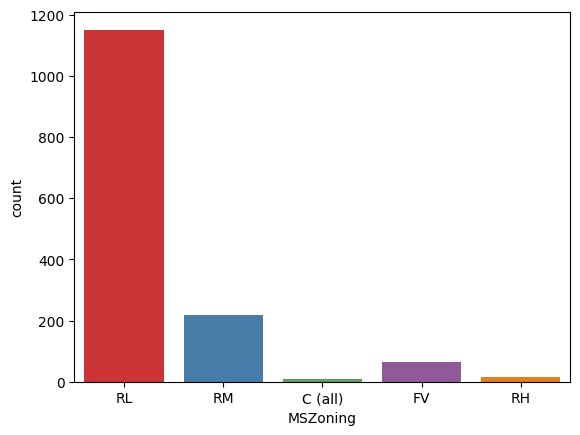

In [127]:
sns.countplot(train, x = 'MSZoning', palette='Set1')
# Most houses sold are in Residential Low Density

### Define the reasons why missing values in each column and the way to replace them
* Missing values in LotFrontage are because of not being recorded
    * Average the LotFrontage with conditions of MSZoning, MSSubclass (reject)
        * it seems like MSZoning and MSSubclass dont have any influence on LotFrontage
    * Average the LotFrontage and fill the missing values with the AVG
* In Alley, there is no clear evidence showing that values are missing because of lack of record 
    * missing values in this column should be filled with NA
* If values in MasVnrType are missing because the values dont exist
    * it will be filled with None 
* If values in MasVnrArea are missing and values in MasVnrType are misisng/none because the values dont exist, 
    * it will be filled with 0
* Missing values in BsmtQal, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2
having relationship with each other.
    * Filling the missing values with NA - NA - NA - 0 - NA
    * In particular, index 948, BsmtExposure is missing but other columns of Bsmt are filled
        * it is potential not recorded, therefore, it can be filled with the most frequent value (No)
* 1 missing value in Electrical is due to lack of record
* If values in Fireplace are 0 because the values might not exist, 
    * then values in FireplaceQu will be filled with NA
* GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond have relationship with each other, if values in one column are missing, they will also be missing in others
    * thereofore, they will be filled with NA
* Missing values in PoolQC, Fence, MiscFeature are because they might not exist
    * Filling them with NA

In [ ]:
# handle missing values in train dataset
## quantitive variables
LotFrontage_avg = train['LotFrontage'].mean()
LotFrontage_avg
train['LotFrontage'] = train['LotFrontage'].fillna(LotFrontage_avg)
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
## categorial variables
train['Alley'] = train['Alley'].fillna('NA')
train['MasVnrType'] = train['MasVnrType'].fillna('None')
train[['BsmtQual','BsmtCond','BsmtFinType1']] = train[['BsmtQual','BsmtCond','BsmtFinType1']].fillna('NA')
train['BsmtExposure'] = train['BsmtExposure'].fillna('NA')
train['BsmtExposure'][948] = train['BsmtExposure'][948].replace('NA','No')
train['Electrical'] = train['Electrical'].fillna('SBrkr')
train['BsmtFinType2'] = train['BsmtFinType2'].fillna('NA')
train['FireplaceQu'] = train['FireplaceQu'].fillna('NA')
train[['GarageType','GarageFinish','GarageQual','GarageCond']] = train[['GarageType','GarageFinish','GarageQual','GarageCond']].fillna('NA')
train['PoolQC'] = train['PoolQC'].fillna('NA')
train['Fence'] = train['Fence'].fillna('NA')
train['MiscFeature'] = train['MiscFeature'].fillna('NA')

C:\Users\Rice\AppData\Local\Temp\ipykernel_5276\3508977255.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  train['BsmtExposure'][948] = train['BsmtExposure'][948].replace('NA','No')
C:\Users\Rice\AppData\Local\Temp\ipykernel_5276\3508977

In [ ]:
# handle missing values in test datasets

In [ ]:
#One-hot coding for category variables having many values

